#### Import libraries :

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp 
from datetime import datetime
print('done!')

done!


## Phase & : Exploratory Data Analysis and Preprocessing With Python

#### 1. Import dataset as DataFrame :

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain


#### 2. check dataset for the missing values :

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntBakedProds        2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

As initial analysis reveals that the Income column contains 24 missing values. Moving forward, we have two primary options: 
1. Deleting these rows 
2. Imputing the missing data using the median. 

Because the dataset is fully complete across all other columns, and we want to preserve that valuable customer data for our analysis, filling the missing income values with the median represents the most appropriate approach.

Note : 
we have detected as well that the label naming of Income has 2 white spaces.
as well for the Dt_customer column detected as object as a datatype not as date.

In [4]:
#renaming the column income to remove the white spaces :
df.rename(columns = {" Income " : "Income"}, inplace = True)

# change the datatype of the column date from "Object" to "Date":
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], 
                                   format='%m/%d/%Y', 
                                   errors='coerce')

# filling the missing values with the median:
df["Income"]= df["Income"].fillna(df['Income'].median())
df[["Income", "Dt_Customer"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Income       2240 non-null   float64       
 1   Dt_Customer  2240 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 35.1 KB


#### 3. checking for duplicated rows 

In [5]:
df.duplicated().sum()

np.int64(0)

Results : there is no duplicated rows 

#### 4. Checking if all the customers are not duplicated in this dataset

In [6]:
df['ID'].duplicated().sum()

np.int64(0)

Results : No duplicated customers in this dataset

#### 5. Adding new and other necessary calculated columns:

In [7]:
# taking on consideration that this dataset can be historical and not a recent.
# we will take the last date recorded in our dataset from the column "Dt_Customer" as a reference. 
# This prevents the inaccurate calculation of Customer Tenure, as well as the age of the customers.
reference_date = df["Dt_Customer"].max()

# Age calculation
df['Age'] = reference_date.year - df['Year_Birth']

# Total Spending across all product categories
df['Total_Spending'] = (df['MntWines'] + df['MntFruits'] + 
                        df['MntMeatProducts'] + df['MntFishProducts'] + 
                        df['MntSweetProducts'] + df['MntBakedProds'])

# Total Dependents
df['Total_Dependents'] = df['Kidhome'] + df['Teenhome']

# Total Campaigns Accepted
df['Total_Campaigns_Accepted'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + 
                                  df['AcceptedCmp3'] + df['AcceptedCmp4'] + 
                                  df['AcceptedCmp5'] + df['Response'])
# Customer Tenure in Days
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days
print(reference_date)
print(reference_date.year)
df.head()

2014-06-29 00:00:00
2014


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Total_Spending,Total_Dependents,Total_Campaigns_Accepted,Customer_Tenure_Days
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,0,1,0,Spain,44,1190,0,1,13
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,1,1,0,Canada,53,577,0,2,14
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,USA,56,251,1,0,47
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,Australia,47,11,2,0,49
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,1,0,Spain,25,91,1,2,82


#### 6. continuous vs discrete variables:

In [8]:
discrete_variables = []
continuous_variables = []
categorical_variables = []
date_variables = []

for var in df.columns :
    if df[var].dtype == 'object' :
        categorical_variables.append(var)

    elif df[var].dtype == 'datetime64[ns]' :
        date_variables.append(var)

    elif df[var].dtype == 'int64' or (df[var].dtype == 'float64' and (df[var].dropna() % 1 == 0).all()):
        discrete_variables.append(var)

    elif df[var].dtype == 'float64' and (df[var].dropna() % 1 != 0).any():
        continuous_variables.append(var)
        
    else:
        print(var, "is unknown")

print("Discrete:", discrete_variables)
print("Continuous:", continuous_variables)
print("Categorical:", categorical_variables)
print("Date_variabes:", date_variables)

Discrete: ['ID', 'Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Age', 'Total_Spending', 'Total_Dependents', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']
Continuous: ['Income']
Categorical: ['Education', 'Marital_Status', 'Country']
Date_variabes: ['Dt_Customer']


In [9]:
# checking and verifiying why the income is a continuous variable :
fractional = df[df['Income'].notna() & (df['Income'] % 1 != 0)]
print("\nHere are a few examples of values that do not end with a .0 suffix:")
fractional.head() 


Here are a few examples of values that do not end with a .0 suffix:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Total_Spending,Total_Dependents,Total_Campaigns_Accepted,Customer_Tenure_Days
134,8996,1957,PhD,Married,51381.5,2,1,2012-11-19,4,230,...,0,0,0,0,Germany,57,603,3,0,587
262,1994,1983,Graduation,Married,51381.5,1,0,2013-11-15,11,5,...,0,0,0,0,USA,31,19,1,0,226
394,3769,1972,PhD,Together,51381.5,1,0,2014-03-02,17,25,...,0,0,0,0,Australia,42,42,1,0,119
449,5255,1986,Graduation,Single,51381.5,1,0,2013-02-20,19,5,...,0,0,0,0,Australia,28,637,1,0,494
525,8268,1961,PhD,Married,51381.5,0,1,2013-07-11,23,352,...,0,0,0,0,Canada,53,404,1,0,353


#### 7. check and verfiying the Categorical variables' unique elements :

In [10]:
#check and verfiying the Categorical variables 
print("Education columns unique elements :",df["Education"].unique())
print("\nMarital_Status columns unique elements :",df["Marital_Status"].unique())
print("\nCountry columns unique elements :",df["Country"].unique())

Education columns unique elements : ['Graduation' 'PhD' '2n Cycle' 'Master' 'Basic']

Marital_Status columns unique elements : ['Divorced' 'Single' 'Married' 'Together' 'Widow' 'YOLO' 'Alone' 'Absurd']

Country columns unique elements : ['Spain' 'Canada' 'USA' 'Australia' 'Germany' 'India' 'Saudi Arabia'
 'Mexico']


From our analysis of unique elements in each column, we can see that the Education and Country columns appear normal. However, in the Marital_Status column, we can clearly see data entry errors such as 'YOLO', 'Alone', and 'Absurd'. but before removing them, We will ensure to count how many times these errors appear in our dataset.

In [11]:
YOLO = len(df[df["Marital_Status"]== "YOLO"])
Alone = len(df[df["Marital_Status"]== "Alone"])
Absurd = len(df[df["Marital_Status"]== "Absurd"])

print(f"YOLO as Marital_Status appears {YOLO} Times")
print(f"Alone as Marital_Status appears {Alone} Times")
print(f"Absurd as Marital_Status appears {Absurd} Times")

YOLO as Marital_Status appears 2 Times
Alone as Marital_Status appears 3 Times
Absurd as Marital_Status appears 2 Times


After counting the occurrences of each of these suspicious marital status types, we can clearly see that the number of occurrences is low, which indicates that these must be data entry errors. Regarding 'Alone' as a marital status, it could actually mean being single, divorced, or widowed. However, it most likely means single, but we should verify this by checking the age of these customers.

- If the age of those customers is younger, then we can assume 'Alone' means single and simply replace 'Alone' with 'Single'.
    
- If the age of the customers is older, then we cannot distinguish whether 'Alone' means single, divorced, or widowed. In that case, the only solution would be dropping those rows to avoid affecting our dataset's statistics.

In [12]:
df.loc[df["Marital_Status"] == "Alone", ["Marital_Status", "Age"]]

,Marital_Status,Age
286,Alone,26
838,Alone,41
959,Alone,56


Based on this analysis, we conclude that the Marital_Status values 'Alone', 'YOLO', and 'Absurd' are data entry errors. With only 7 occurrences out of 2,040 total records (representing just 0.34% of the dataset), removing these rows is a reasonable decision that will not significantly impact the dataset's integrity or statistical power

In [13]:
#dropping the Invalid marital Status whole rows 
list_invalid_Marital_Status = ['YOLO', 'Alone', 'Absurd']
df_invalid_Marital_Status = df["Marital_Status"].isin(list_invalid_Marital_Status)
df = df[~df_invalid_Marital_Status]

#verification :
df["Marital_Status"].unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow'], dtype=object)

#### 8. after cleaning, Applying Summary Metrics to Detect pattern of Data Errors and Anomalies using describe() function as our last data exploratory step : 

In [14]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Age,Total_Spending,Total_Dependents,Total_Campaigns_Accepted,Customer_Tenure_Days
count,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233,2233.000000,2233.000000,2233.000000,2233.000000,...,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000
mean,5595.398567,1968.790864,52234.708016,0.444245,0.506046,2013-07-10 10:37:08.034034688,49.172414,304.033587,26.300940,167.113300,...,0.072548,0.064039,0.013435,0.148231,0.009404,45.209136,605.904613,0.950291,0.445589,353.557546
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.000000,0.000000,0.000000,0.000000
25%,2831.000000,1959.000000,35523.000000,0.000000,0.000000,2013-01-17 00:00:00,24.000000,24.000000,1.000000,16.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,37.000000,68.000000,0.000000,0.000000,181.000000
50%,5462.000000,1970.000000,51381.500000,0.000000,0.000000,2013-07-09 00:00:00,50.000000,173.000000,8.000000,67.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,44.000000,396.000000,1.000000,0.000000,355.000000
75%,8430.000000,1977.000000,68316.000000,1.000000,1.000000,2013-12-30 00:00:00,74.000000,505.000000,33.000000,232.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,1045.000000,1.000000,1.000000,528.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,121.000000,2525.000000,3.000000,5.000000,699.000000
std,3243.198115,11.979248,25062.791884,0.538528,0.544675,NaN,28.962114,336.953019,39.779532,225.870588,...,0.259451,0.244878,0.115153,0.355408,0.096541,11.979248,602.697511,0.751785,0.889414,201.971642


From our analysis using the describe function, we can see that there are some aberrant values and data entry errors:

1. The Age column shows a maximum age of 121 (which corresponds to a Year_Birth of 1893). While this is possible, this shows a classic "Data Error" caused by users selecting the oldest possible year in a registration dropdown menu to bypass age restrictions or by mistake.
Impact: Leaving this in will severely stretch the demographic distribution scales in future visualizations.

2. The maximum Income in the dataset is $666,666. As the 75th percentile of income is $68,289, and the mean is $52,237 then the max value is more than 10x the median $51,381.5 . which indicate that the data entry of the income "666,666" is highly likely a data entry error.
Impact: This single entry will warp scatter plots comparing income to total spending and significantly skew correlation algorithms.

In [15]:
#action for fixing the age data error :
df= df[(df["Age"] >=18) & (df["Age"] <= 90)]

unique_ages = df["Age"].unique()
print("min age in the df : ",unique_ages.min())  
print("max age in the df : ",unique_ages.max())    
print( len(df["Age"].unique()))      


min age in the df :  18
max age in the df :  74
56


Before removing the suspected $666,666 income data entry error, we must visually verify whether this value is a genuine high-earning customer or a fake registration. We will plot the distribution of income against total spending, using the $100k salary mark as a reference point to compare these extreme outliers against our standard customer base.

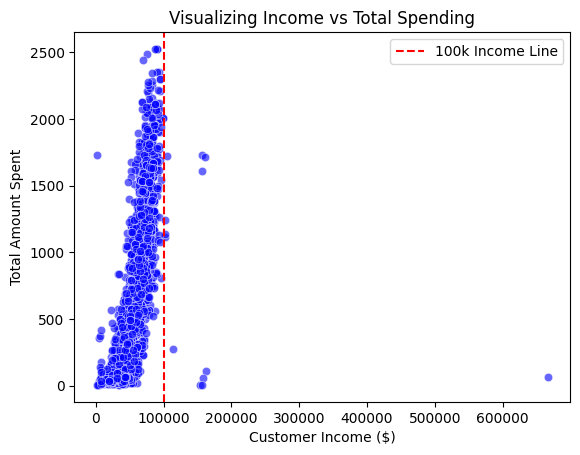

<Figure size 1000x600 with 0 Axes>


There are 13 customers with an Income over $100k.


In [16]:
# Plot Income vs Total Spending
sns.scatterplot(
    data=df, 
    x='Income', 
    y='Total_Spending', 
    alpha = 0.6, 
    color='blue'
)

# Drawing a Red vertical line at the 100k income
plt.axvline(x=100000, 
            color='red', 
            linestyle='--', 
            label='100k Income Line')

# Format the graph
plt.title("Visualizing Income vs Total Spending")
plt.xlabel("Customer Income ($)")
plt.ylabel("Total Amount Spent")
plt.legend()
plt.figure(figsize=(10, 6))


plt.show()

# people who make over than 100k :
high_earners = df[df['Income'] >= 100000]
print(f"\nThere are {len(high_earners)} customers with an Income over $100k.")


Based on the scatter plot, we discovered 13 customers with an income greater than or equal to $100k. While 12 of these customers show a normal, expected pattern (staying under $200k), only one isolated value exceeds $600k. Given this extreme gap and the user's lack of spending, this $600k+ value is clearly a suspicious data entry error. This visual gap confirms that the 12 customers under $200k are genuinely our high-income VIPs, whereas the $600k+ record is highly suspicious and should be treated as a data entry error rather than a real customer.

In [17]:
# dropping the extreme income values :
df = df[df["Income"] <= 200000]

income_greater_than_100k = len(df[df["Income"] >= 100000])
print(f"customers with income higher than $100k are: {income_greater_than_100k} Customers")

customers with income higher than $100k are: 12 Customers


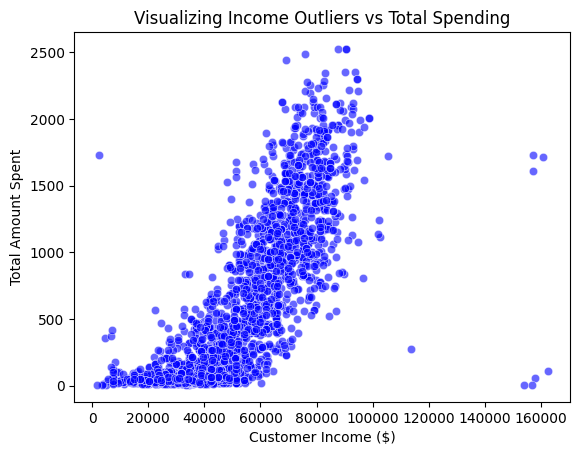

<Figure size 1000x600 with 0 Axes>

In [18]:
# Plot Income vs Total Spending
sns.scatterplot(
    data=df, 
    x='Income', 
    y='Total_Spending', 
    alpha=0.6, 
    color='blue'
)

# Format the graph
plt.title("Visualizing Income Outliers vs Total Spending")
plt.xlabel("Customer Income ($)")
plt.ylabel("Total Amount Spent")
plt.figure(figsize=(10, 6))
plt.show()

# Phase 2 : Data Analysis


## Task 1: Demographics Profiling (Who are our customers?)

#### 1. Effect of education on the income :

In [19]:
#first organizing the education levels in the graph 
df["Education"].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

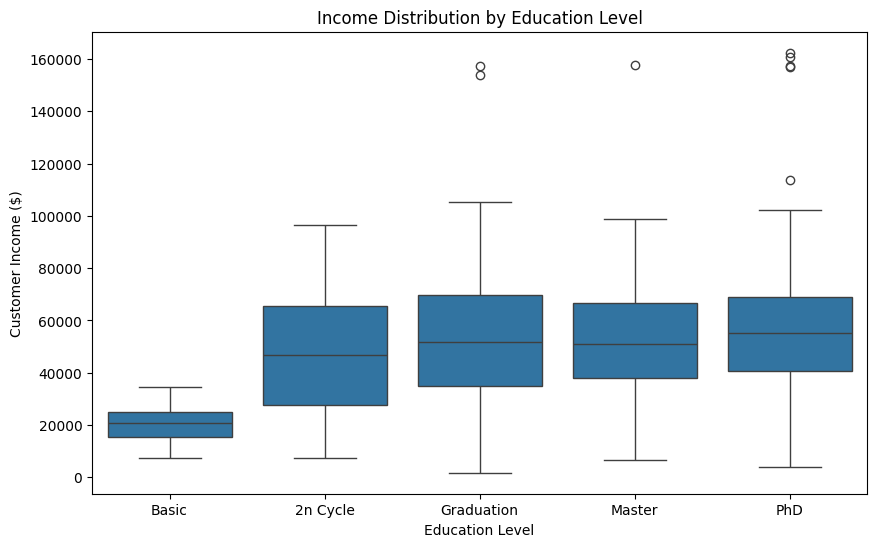

In [20]:
plt.figure(figsize=(10, 6))
education_levels_in_order =['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
# Create the boxplot
sns.boxplot(data=df, x='Education', y='Income', order = education_levels_in_order)

plt.title('Income Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Customer Income ($)')

plt.show()

Based on the boxplot analysis, which reveals that income rises with education level (the more educated the customer, the higher their income), this insight helps us distinguish customers with strictly limited purchasing power from the highest-earning VIPs who have greater purchasing power.

Action : our marketing compagnes should target people with higher education levels

#### 2. Age distribution Analysis :

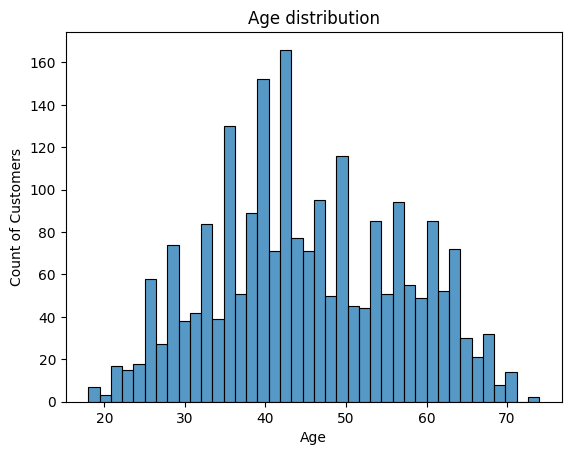

In [21]:
sns.histplot(data=df, x='Age', bins=40) 
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count of Customers')

plt.show()

The age distribution shows that the majority of customers are concentrated between approximately 28 and 63 years old, with the highest count of customers occurring around age 38 and 46 years Old. Customer counts decline notably for ages below 28 and above 63 years old

Action : our marketing compagnes should target people with age in range between 28 and 63 years old

#### 3. Marital status distribution Analysis :

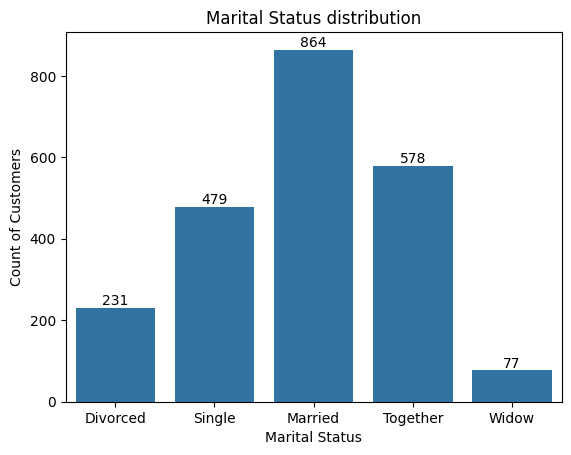

In [22]:
plot = sns.countplot(data=df, x='Marital_Status')
plt.title('Marital Status distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count of Customers')

plot.bar_label(plot.containers[0])
plt.show()

From our analysis of the marital status distribution, the barplot reveals that most customers are in an ongoing relationship, with "Married" and "Together" representing the largest segments. This suggests that being in a relationship has a positive effect on customers' willingness to purchase our products. In contrast, divorced (231) and widowed (77) customers show notably lower counts, which may indicate different spending behaviors or financial constraints compared to those in active relationships.

Interestingly, the "Single" marital status category demonstrates a surprisingly positive spending behavior, despite not being in a relationship.

Interpretation from a Social Engineering Perspective:

Customers in Ongoing Relationships (Married & Together) often require increased spending due to commitment, shared daily routines, cooking, and meals prepared at home. Married customers tend to spend more than those who are "Together," as marriage typically implies shared household responsibilities, including regular home-cooked meals and daily necessities. In contrast, "Together" as a more open or less formal relationship may not carry the same level of domestic obligation, potentially leading to different spending patterns.

Single Customers: Singles exhibit positive spending behavior, likely because they manage all household tasks and expenses independently, including cooking, dining, and daily living costs, without the support of a partner.

Divorced or Widowed Customers: The lower spending among divorced or widowed individuals may reflect the emotional and practical consequences of their status. Without the warmth and structure of a shared home environment—such as cooking meals together or maintaining a household, these customers may exhibit different spending behaviors, shifted financial priorities, or face financial constraints compared to those in active relationships.

Action : to even optimize our marketing campaigns, we should prioritize the customers within active relationship and Singles.

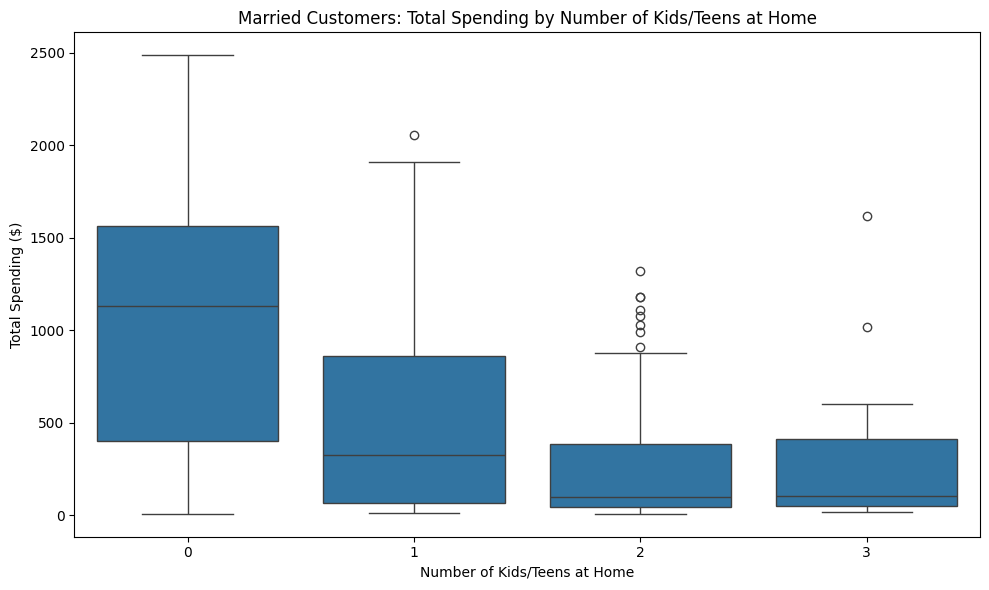

In [23]:
married_df = df[df['Marital_Status']=='Married']
plt.figure(figsize=(10, 6))
sns.boxplot(data=married_df, x='Total_Dependents', y='Total_Spending')  # or your spending column
plt.title('Married Customers: Total Spending by Number of Kids/Teens at Home')
plt.xlabel('Number of Kids/Teens at Home')
plt.ylabel('Total Spending ($)')
plt.tight_layout()
plt.show()

In [24]:
print(married_df['Total_Dependents'].value_counts())

Total_Dependents
1    449
0    230
2    168
3     17
Name: count, dtype: int64


Based on the boxplot analysis, which reveals the relationship between the number of dependents (kids and teens at home) and total spending among married customers, we can clearly see that there is an inverse relationship: the more dependents a married customer has, the less they spend on our products.

Married customers with 0 dependents are by far the highest spenders, while customers with 1 dependent spends more much less. Customers with 2 or 3 dependents show even lower spending, with medians around $100.

This pattern is consistent with consumer behavior theory: married couples without children ("DINK" : Dual Income, No Kids) have more discretionary income available for premium purchases such as wines and specialty food products. As the number of dependents increases, the household budget is stretched further by expenses like clothing, school fees, and daily necessities, leaving less room for premium product purchases.

Action : our marketing campaigns should prioritize married couples with 0 dependents, as they represent the highest spending potential among married customers.


### Task 2: Product Purchasing Habits (What do they buy?)

 #### 1. Pie chart or Bar chart showing the Total Revenue generated by each product category 

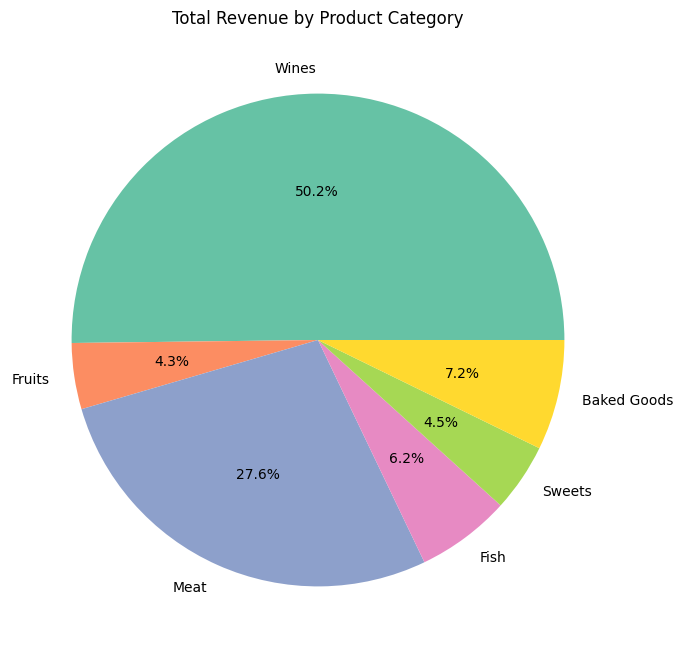

In [25]:
# Total Revenue by Product Category
products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']
labels = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Baked Goods']
# Calculate total revenue for each category
totals = [df[Mnt].sum() for Mnt in products]
# Plot
plt.figure(figsize=(8, 8))
plt.pie(totals, 
        labels=labels, 
        autopct='%1.1f%%', 
        #startangle=90,
        colors=sns.color_palette("Set2"))
plt.title('Total Revenue by Product Category')
plt.show()

In [26]:
print(f"Total sales of all products = {sum(totals)}$")

Total sales of all products = 1350983$


 #### 2. the correlation between income vs spending :

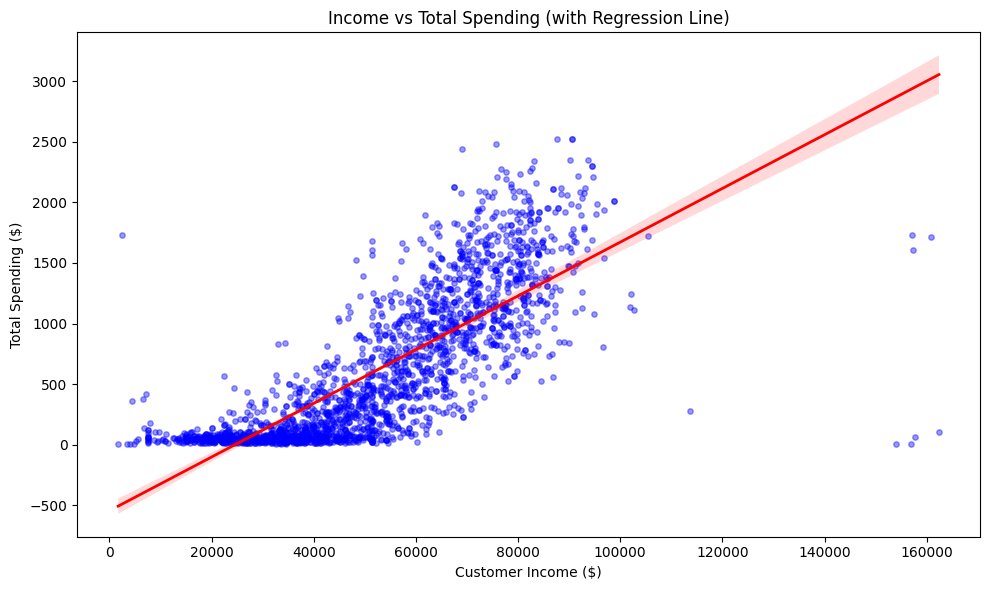

In [27]:
# Scatter plot with Regression Line: Income vs Total Spending
plt.figure(figsize=(10, 6))
sns.regplot(data=df, 
            x='Income', 
            y='Total_Spending', 
            scatter_kws={'alpha': 0.4, 'color': 'blue', 's': 15},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Income vs Total Spending (with Regression Line)')
plt.xlabel('Customer Income ($)')
plt.ylabel('Total Spending ($)')
plt.tight_layout()
plt.show()


Based on the regression plot analysis, we can clearly observe a strong positive correlation between customer income and total spending on our products. The red regression line confirms that as income increases, total spending increases proportionally, which validates the logical assumption that customers with higher purchasing power tend to spend more on our products.

A key observation is the $60,000 income threshold which acts as a clear breakpoint in spending behavior. The majority of customers with an income under $60,000 tend to spend less than $500 on our products. However, once income exceeds $60,000, we can see the data spreading positively and increasing significantly, showcasing that customers with income above $60,000 tend to spend considerably more. This suggests that the $60,000 mark represents a critical income level where customers transition from budget-conscious buyers to higher-value spenders.

Action : since income is a strong predictor of spending with a clear breakpoint at $60,000, our marketing campaigns should focus on attracting and retaining customers with incomes above $60,000, where spending potential increases significantly, while also investigating disengaged high-income customers for possible re-activation campaigns.


#### 3. Statistical test to confirm/deny the correlation between income and spending:

for this test we will use pearson, Although pearson used in cont-cont variables combinations, and Total_Spending is technically discrete, it spans hundreds of distinct values (0–2000$+),
closely approximating a continuous distribution.
Combined with the linear trend confirmed visually by
the regression plot, Pearson remains a valid and accepted choice for this analysis.

for the test :
HO : Total_Spending and Income are not correlated 
H1 : Total_Spending and Income are correlated 
Alpha = 0.05
Confidance = 95%


In [38]:
alpha = 0.05
r, p_value = sp.stats.pearsonr(df["Total_Spending"], df["Income"])

if p_value < alpha:
    print(f"Reject H0: There is a statistically significant correlation (r = {r:.3f}, p = {p_value:e}).")
else:
    print(f"Fail to reject H0: No statistically significant correlation (r = {r:.3f}, p = {p_value:e}).")

Reject H0: There is a statistically significant correlation (r = 0.789, p = 0.000000e+00).


In [ ]:
# Spearman Rank 
rho, p_val_spearman = sp.stats.spearmanr(df["Total_Spending"], df["Income"])

if p_val_spearman < alpha:
    print(f"Reject H0 (Spearman): There is a statistically significant correlation (rho = {rho:.3f}, p = {p_val_spearman:e}).")
else:
    print(f"Fail to reject H0 (Spearman): No statistically significant correlation (rho = {rho:.3f}, p = {p_val_spearman:e}).")


Reject H0 (Spearman): There is a statistically significant correlation (rho = 0.849, p = 0.000000e+00).


#### 4. Spending per Product by country :

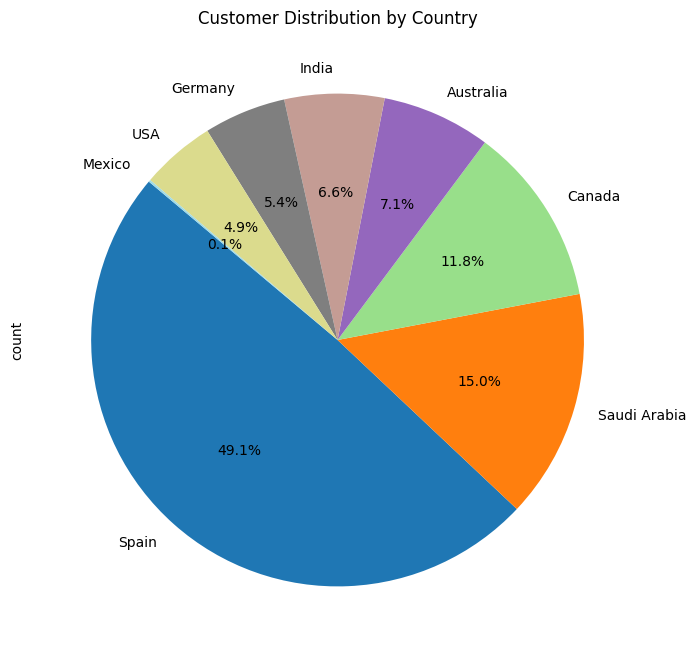

Country
Spain           1094
Saudi Arabia     335
Canada           263
Australia        159
India            146
Germany          120
USA              109
Mexico             3
Name: count, dtype: int64


In [52]:
# Calculate the number of customers per country
country_counts = df['Country'].value_counts()

# Create a pie chart
plt.figure(figsize=(10, 8))
country_counts.plot(kind='pie', 
                    autopct='%1.1f%%',   
                    startangle=140,      
                    cmap='tab20' 
                    ) 

plt.title('Customer Distribution by Country')

plt.show()

print(country_counts)


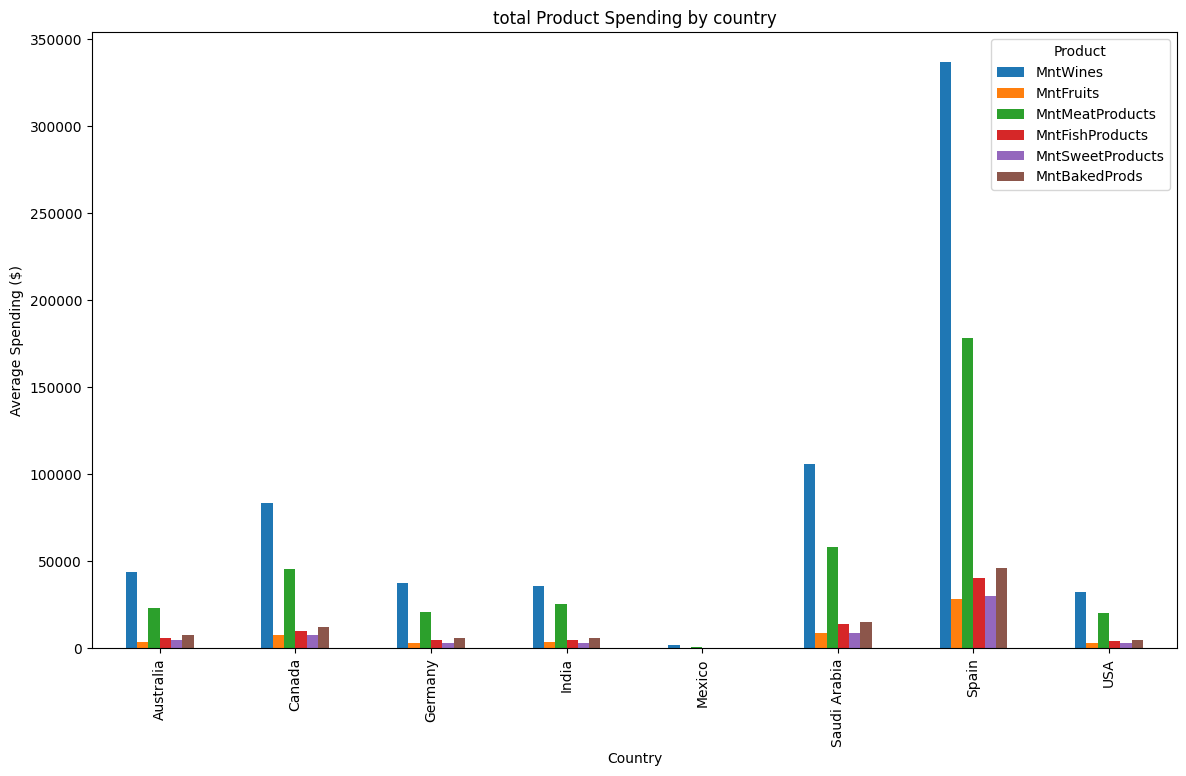

In [ ]:
# total Spending per Product by country
products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']

avg_spending = df.groupby('Country')[products].sum()


avg_spending.plot(kind='bar', figsize=(14, 8))
plt.title('total Product Spending by country')
plt.xlabel('Country')
plt.ylabel('Total Spending ($)')
plt.legend(title='Product')

plt.show()


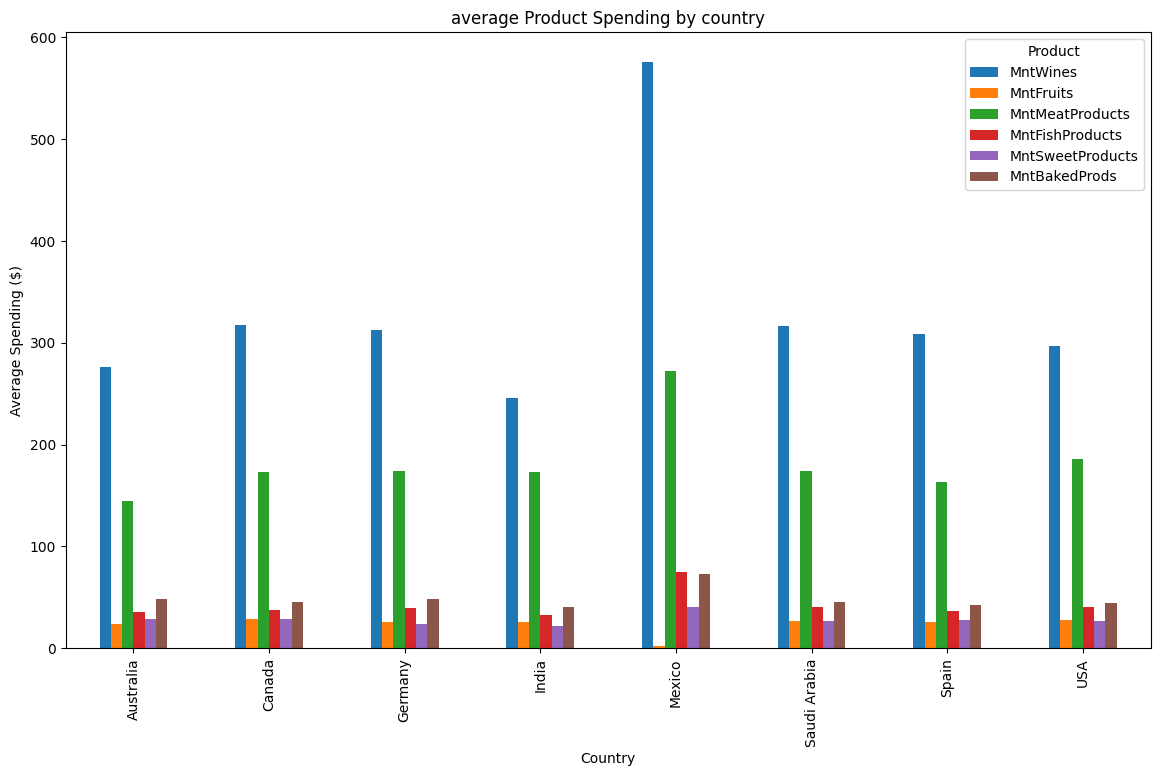

In [54]:
# avg Spending per Product by country
products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds']

avg_spending = df.groupby('Country')[products].mean()


avg_spending.plot(kind='bar', figsize=(14, 8))
plt.title('average Product Spending by country')
plt.xlabel('Country')
plt.ylabel('Average Spending ($)')
plt.legend(title='Product')

plt.show()


By comparing the average individual spending against total sales volumes across different countries, we identified that our largest customer bases are in Spain and Saudi Arabia. However, an analysis of average spending per individual reveals a massive untapped opportunity: despite only having 3 customers from Mexico, they are our highest-value individual buyers, dramatically outspending the average customer in categories like Wine, Fish, and Baked Products. Interestingly, this high-spending demographic showed absolutely near zero interest in Fruit products.

Marketing Recommendations: To optimize our future campaigns based on this data, we recommend introducing a targeted customer acquisition campaign in Mexico focusing exclusively on Wine, Fish, and Baked Products, while completely omitting Fruits to maximize our Return on Ad Spend (ROAS). Additionally, we should maintain our broad, steady marketing efforts in Spain and Saudi Arabia, as they remain the foundational cash cows of our business.

## Phase 3 :Export Cleaned Data to Power BI for dynamic dashbaords: 

In [30]:
df.to_csv('customer_data.csv', index=False, sep=';')